# 9. Practical Training Challenges
---
Real neural networks face several common issues that prevent training from working well. This notebook covers the most important ones — and how to fix them.


## 9.0 The Vanishing Gradient Problem (Preview)

When you stack sigmoid/tanh layers, gradients get **multiplied** during backprop.  
Since sigmoid derivatives are at most 0.25, gradients shrink exponentially:

$$0.25^{10} \approx 0.000001$$

Early layers receive **almost no gradient signal** → they don't learn!

**ReLU** avoids this because its derivative is either 0 or 1 (for positive inputs).

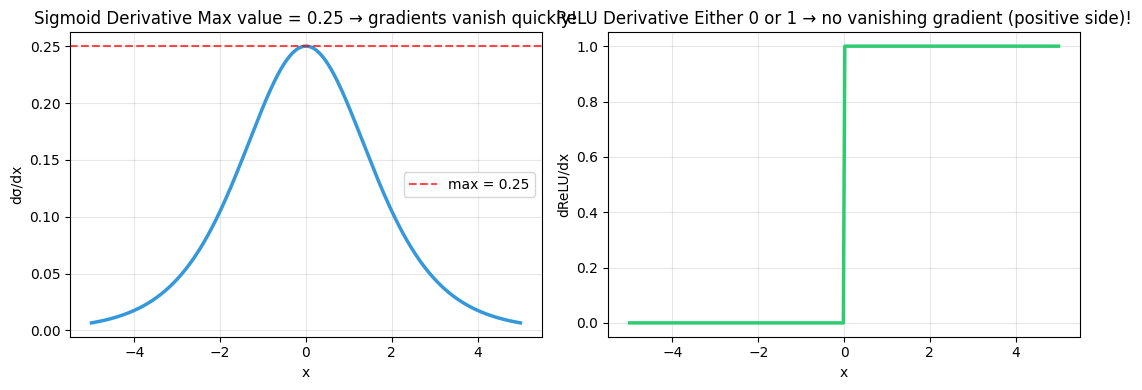

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# All activation functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x):    return np.tanh(x)
def relu(x):    return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def gelu(x):    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

# Visualizing vanishing gradients across layers
def sigmoid_derivative(x): 
    return sigmoid(x) * (1 - sigmoid(x))
def relu_derivative(x): 
    return (x > 0).astype(float)

x_range = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Sigmoid derivative
axes[0].plot(x_range, sigmoid_derivative(x_range), color='#3498DB', lw=2.5)
axes[0].set_title("Sigmoid Derivative Max value = 0.25 → gradients vanish quickly!")
axes[0].set_xlabel("x"); axes[0].set_ylabel("dσ/dx")
axes[0].axhline(0.25, color='red', linestyle='--', alpha=0.7, label='max = 0.25')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ReLU derivative
axes[1].plot(x_range, relu_derivative(x_range), color='#2ECC71', lw=2.5)
axes[1].set_title("ReLU Derivative Either 0 or 1 → no vanishing gradient (positive side)!")
axes[1].set_xlabel("x"); axes[1].set_ylabel("dReLU/dx")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9.1 Vanishing & Exploding Gradients

During backprop, gradients are **multiplied** at each layer.

- If values < 1 repeatedly: gradients **vanish** → early layers don't learn
- If values > 1 repeatedly: gradients **explode** → weights blow up → NaN

This is especially bad for deep networks (>10 layers) and RNNs.

**Fixes:**
- Use **ReLU** (derivative is 0 or 1)
- Proper **weight initialization**
- **Batch normalization**
- **Gradient clipping** (for exploding)


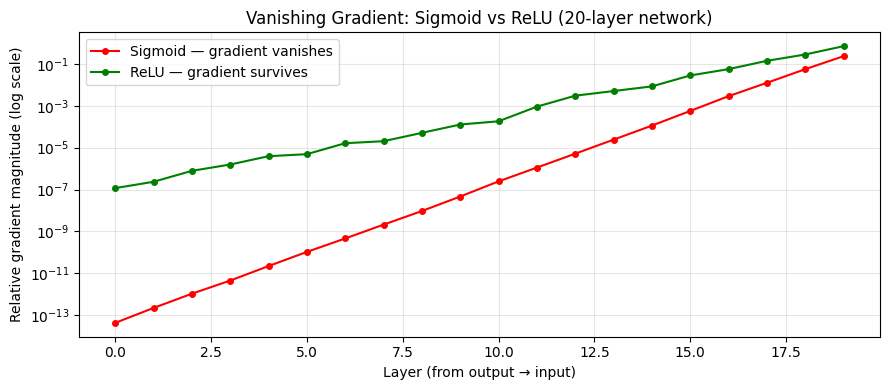

In [6]:


np.random.seed(42)

def sigmoid(z): return 1 / (1 + np.exp(-z))
def relu(z): return np.maximum(0, z)

# Simulate gradient flow through 20 layers (just tracking the scale)
n_layers = 20
x = np.random.randn(10, 1)

# With sigmoid (gradient ~ 0.25 per layer)
grads_sigmoid = []
a = x.copy()
for _ in range(n_layers):
    W = np.random.randn(10, 10) * 0.5
    z = W @ a
    a = sigmoid(z)
    # Gradient scale at each layer ≈ product of sigmoid derivatives
    grads_sigmoid.append(np.mean(np.abs(sigmoid(z) * (1 - sigmoid(z)))))

# Running product (simulates what backprop does)
sig_running = np.cumprod(grads_sigmoid[::-1])[::-1]

# With ReLU (gradient ~ 1 for positive inputs)
grads_relu = []
a = x.copy()
for _ in range(n_layers):
    W = np.random.randn(10, 10) * np.sqrt(2/10)  # He init
    z = W @ a
    a = relu(z)
    grads_relu.append(np.mean((z > 0).astype(float)))

relu_running = np.cumprod(grads_relu[::-1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(sig_running, 'r-o', markersize=4, label='Sigmoid — gradient vanishes')
plt.plot(relu_running, 'g-o', markersize=4, label='ReLU — gradient survives')
plt.yscale('log')
plt.xlabel('Layer (from output → input)')
plt.ylabel('Relative gradient magnitude (log scale)')
plt.title('Vanishing Gradient: Sigmoid vs ReLU (20-layer network)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9.2 Weight Initialization

**Why it matters:** If weights start too large → activations saturate, gradients vanish. Too small → activations shrink to zero, no learning.

### Xavier Initialization (for Sigmoid/Tanh)
$$W \sim \mathcal{N}\left(0, \frac{1}{n_{\text{in}}}\right)$$

### He Initialization (for ReLU) ← most common today
$$W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}}}\right)$$

The idea: keep the **variance of activations** roughly the same across all layers.


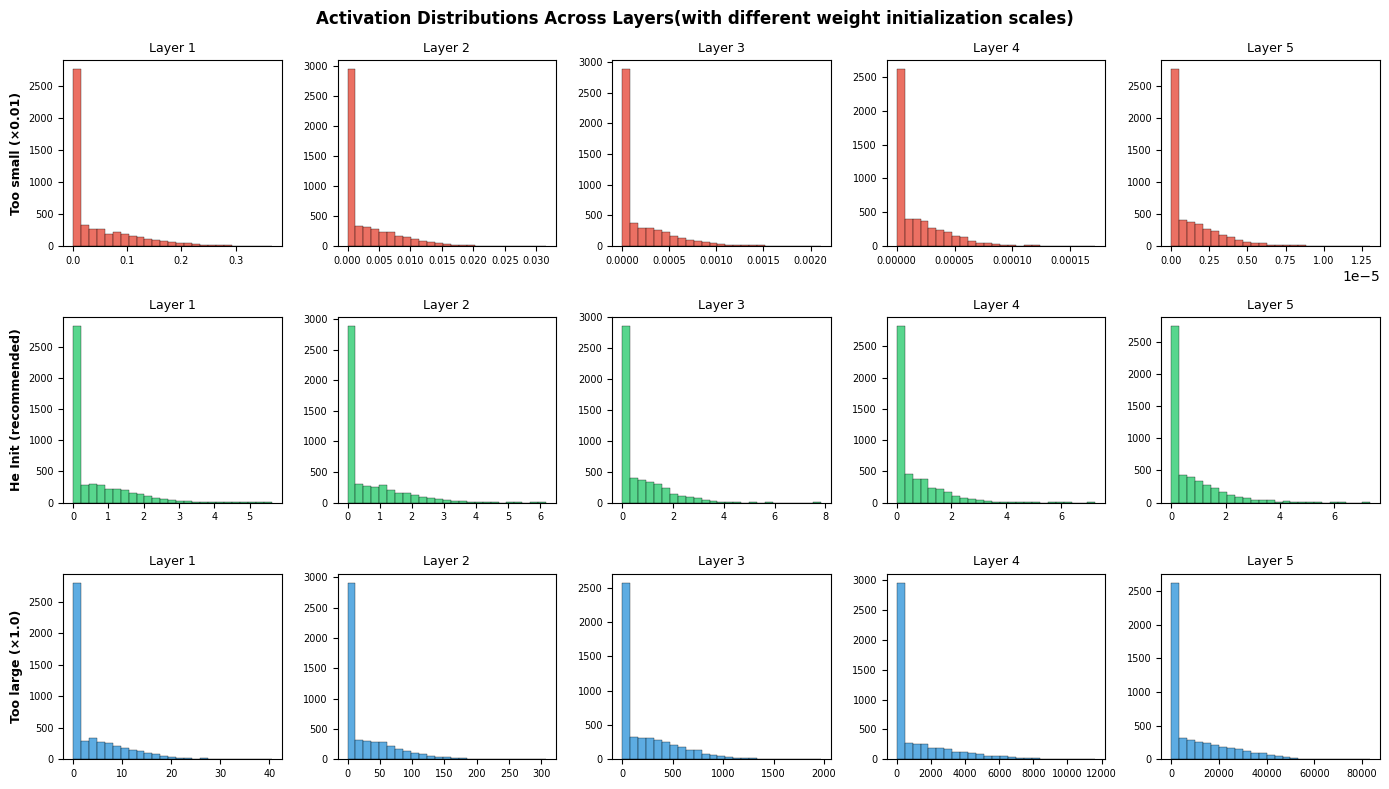

Small weights → activations collapse to 0 (no signal)
Large weights → activations explode or saturate
He init → healthy distribution throughout ✓


In [9]:
# Visualizing the effect of initialization on activation distributions
n_layers = 5
n_neurons = 100
x = np.random.randn(n_neurons, 50)   # 50 samples

fig, axes = plt.subplots(3, n_layers, figsize=(14, 8))

init_configs = [
    ("Too small (×0.01)", 0.01,                   '#E74C3C'),
    ("He Init (recommended)", np.sqrt(2/n_neurons), '#2ECC71'),
    ("Too large (×1.0)",  1.0,                    '#3498DB'),
]

for row, (name, scale, col) in enumerate(init_configs):
    a = x.copy()
    for l in range(n_layers):
        W = np.random.randn(n_neurons, n_neurons) * scale
        z = W @ a
        a = relu(z)
        axes[row, l].hist(a.flatten(), bins=25, color=col, alpha=0.8, edgecolor='k', lw=0.3)
        axes[row, l].set_title(f"Layer {l+1}", fontsize=9)
        if l == 0:
            axes[row, l].set_ylabel(name, fontsize=9, fontweight='bold')
        axes[row, l].tick_params(labelsize=7)

plt.suptitle("Activation Distributions Across Layers(with different weight initialization scales)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Small weights → activations collapse to 0 (no signal)")
print("Large weights → activations explode or saturate")
print("He init → healthy distribution throughout ✓")


## 9.3 Batch Normalization

**Idea:** After each layer, **normalize** the activations to have mean ≈ 0 and std ≈ 1.

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \cdot \gamma + \beta$$

Where $\mu_B$, $\sigma_B^2$ are the mean and variance of the current **mini-batch**.  
$\gamma$ and $\beta$ are **learnable** parameters (let the network undo normalization if needed).

**Benefits:**
- Reduces internal covariate shift
- Allows higher learning rates
- Acts as a regularizer (slight noise from batch statistics)
- Less sensitive to weight initialization


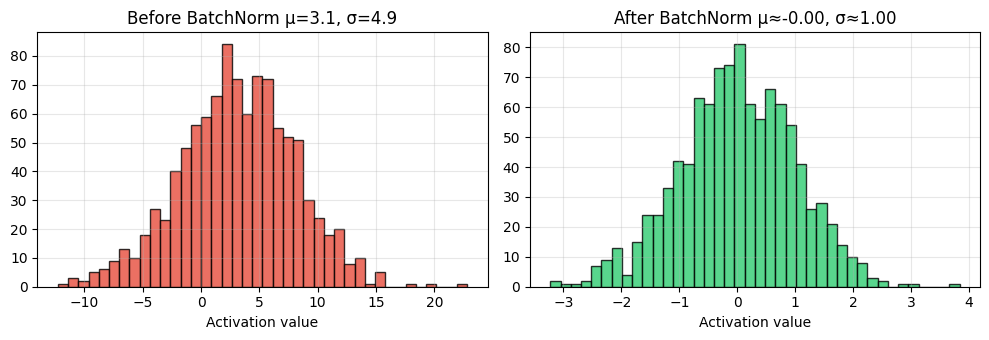

In [11]:
class BatchNorm:
    def __init__(self, n_features, eps=1e-8):
        self.gamma = np.ones(n_features)   # learnable scale
        self.beta  = np.zeros(n_features)  # learnable shift
        self.eps = eps

    def forward(self, x):
        # x shape: (batch_size, n_features)
        self.mu    = x.mean(axis=0)
        self.sigma = x.std(axis=0)
        self.x_hat = (x - self.mu) / (self.sigma + self.eps)
        return self.gamma * self.x_hat + self.beta

# Demo: batch norm stabilizes activations
np.random.seed(1)
batch = np.random.randn(64, 16) * 5 + 3   # very off-distribution

bn = BatchNorm(16)
normalized = bn.forward(batch)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(batch.flatten(), bins=40, color='#E74C3C', alpha=0.8, edgecolor='k')
axes[0].set_title(f"Before BatchNorm μ={batch.mean():.1f}, σ={batch.std():.1f}")
axes[1].hist(normalized.flatten(), bins=40, color='#2ECC71', alpha=0.8, edgecolor='k')
axes[1].set_title(f"After BatchNorm μ≈{normalized.mean():.2f}, σ≈{normalized.std():.2f}")
for ax in axes: ax.set_xlabel("Activation value"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9.4 Overfitting: Dropout & Regularization

**Overfitting** = model memorizes training data, fails on new data.

### Dropout
During training, randomly **zero out** neurons with probability $p$ (typically 0.2–0.5).  
- Forces network not to rely on any single neuron
- Acts as an ensemble of many networks
- At test time, dropout is OFF (all neurons active, weights scaled)

### L2 Regularization (Weight Decay)
Add a penalty for large weights to the loss:

$$L_{\text{total}} = L_{\text{BCE}} + \lambda \sum_w w^2$$

This discourages the model from fitting noise.


In [12]:
def dropout(a, p_keep=0.8, training=True):
    """p_keep = probability of keeping a neuron active"""
    if not training:
        return a  # no dropout at test time
    mask = (np.random.rand(*a.shape) < p_keep) / p_keep  # inverted dropout
    return a * mask

# Example
np.random.seed(0)
a = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])

a_train = dropout(a, p_keep=0.5, training=True)
a_test  = dropout(a, p_keep=0.5, training=False)

print("Original activations:        ", a)
print("After dropout (training):    ", a_train)
print("After dropout (test/eval):   ", a_test)
print()
print("Note: active values are scaled by 1/p_keep to preserve expected sum")
print(f"Sum original:  {a.sum():.1f}")
print(f"Sum training:  {a_train.sum():.1f}  (some zeros, but active ones scaled up)")
print(f"Sum test:      {a_test.sum():.1f}")


Original activations:         [1. 2. 3. 4. 5. 6. 7. 8.]
After dropout (training):     [ 0.  0.  0.  0. 10.  0. 14.  0.]
After dropout (test/eval):    [1. 2. 3. 4. 5. 6. 7. 8.]

Note: active values are scaled by 1/p_keep to preserve expected sum
Sum original:  36.0
Sum training:  24.0  (some zeros, but active ones scaled up)
Sum test:      36.0
